In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [72]:
df = pd.read_csv('dirty_cafe_sales.csv')
print("Data loaded successfully.")

# Data inspection
df.head(40)

Data loaded successfully.


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [73]:
# Show non-null info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [74]:
# Cleaning

# Handling missing values

error_values = ["ERROR", "UNKNOWN", "NaN"]

# Handle Numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    df[col].replace(error_values, median_value, inplace=True)


# Handle Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
    df[col].fillna(mode_value, inplace=True)
    df[col].replace(error_values, mode_value, inplace=True)

# Handle Transaction Date column
date_cols = ['Transaction Date']
median_date = pd.to_datetime(df['Transaction Date'], errors='coerce').median()
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors='coerce')
df["Transaction Date"].fillna(median_date, inplace=True)

# Parse the numerical values
# Convert Quantity to int
df['Quantity'] = df['Quantity'].astype(int)

# Convert Total Spent and Price Per Unit to float
df['Total Spent'] = df['Total Spent'].astype(float)
df["Price Per Unit"] = df['Price Per Unit'].astype(float)

print("Missing values handled.")
print("=" * 40)
print("Post-cleaning data info:")
df.info()
print("=" * 40)
print("Post-cleaning data preview:")
df.head(40)

Missing values handled.
Post-cleaning data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  int64         
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  object        
 6   Location          10000 non-null  object        
 7   Transaction Date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 625.1+ KB
Post-cleaning data preview:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,6.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Takeaway,2023-03-31
6,TXN_4433211,Juice,3,3.0,9.0,Digital Wallet,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,Takeaway,2023-10-28
8,TXN_4717867,Juice,5,3.0,15.0,Digital Wallet,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31


In [75]:
from calendar import month_name
# Feature Engineering

# get the categories of items sold
unique_food_values = df["Item"].unique()
print("Unique items sold:", unique_food_values)

foods = ["Cake", "Cookie", "Salad", "Sandwich"]
print("Food items:", foods)
print("Drink items:", [item for item in unique_food_values if item not in foods])

df["Category"] = df["Item"].apply(lambda x: "Food" if x in foods else "Drink")

# Get the transaction Month
# if date is ERROR or UNKNOWN, fill with NaT
df['Transaction Month'] = pd.to_datetime(df['Transaction Date'], errors='coerce').dt.month_name()
df['Transaction Month'].fillna("No Date", inplace=True)

# Add a day of week column
df['Day of Week'] = pd.to_datetime(df['Transaction Date'], errors='coerce').dt.day_name()

df.head(40)

Unique items sold: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Juice' 'Sandwich' 'Tea']
Food items: ['Cake', 'Cookie', 'Salad', 'Sandwich']
Drink items: ['Coffee', 'Smoothie', 'Juice', 'Tea']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Category,Transaction Month,Day of Week
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,Drink,September,Friday
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,Food,May,Tuesday
2,TXN_4271903,Cookie,4,1.0,6.0,Credit Card,In-store,2023-07-19,Food,July,Wednesday
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,Food,April,Thursday
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,Drink,June,Sunday
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Takeaway,2023-03-31,Drink,March,Friday
6,TXN_4433211,Juice,3,3.0,9.0,Digital Wallet,Takeaway,2023-10-06,Drink,October,Friday
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,Takeaway,2023-10-28,Food,October,Saturday
8,TXN_4717867,Juice,5,3.0,15.0,Digital Wallet,Takeaway,2023-07-28,Drink,July,Friday
9,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31,Food,December,Sunday


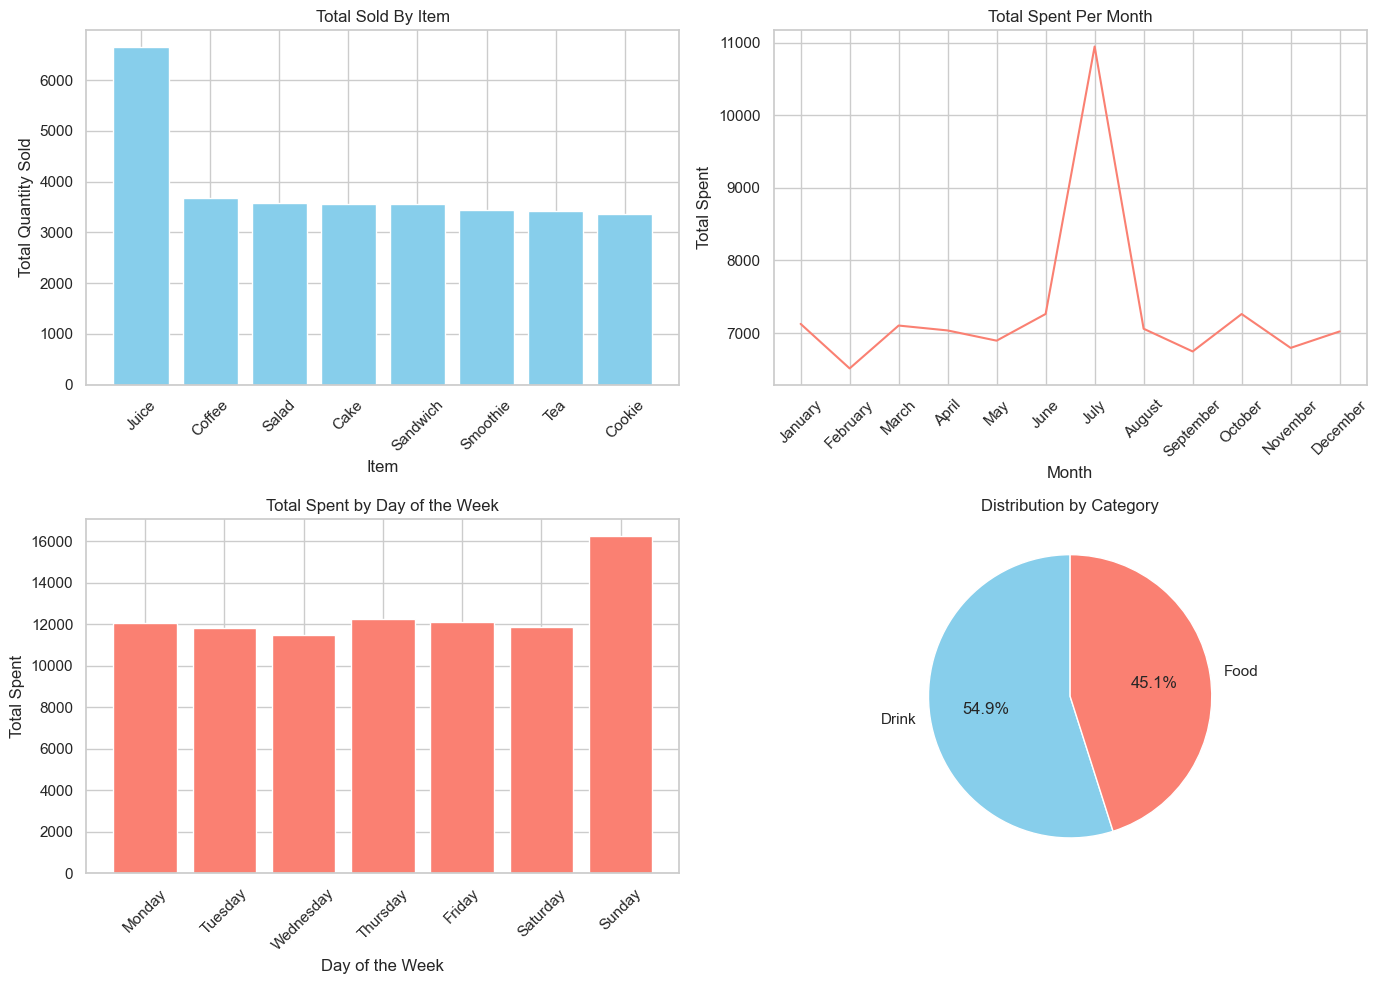

In [86]:
# Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Sold By Item
total_sold_by_item = df.groupby('Item')['Quantity'].sum().reset_index().sort_values(by='Quantity', ascending=False)

axes[0, 0].bar(total_sold_by_item['Item'], total_sold_by_item['Quantity'], color='skyblue')
axes[0, 0].set_title('Total Sold By Item')
axes[0, 0].set_xlabel('Item')
axes[0, 0].set_ylabel('Total Quantity Sold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Total Per Month
total_per_month = df.groupby('Transaction Month')['Total Spent'].sum().reindex(list(month_name)[1:]).reset_index()

axes[0, 1].plot(total_per_month['Transaction Month'], total_per_month['Total Spent'], color='salmon')
axes[0, 1].set_title('Total Spent Per Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Total Spent')
axes[0, 1].tick_params(axis='x', rotation=45)

# Day of the Week Analysis
sales_by_day = df.groupby('Day of Week')['Total Spent'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

axes[1, 0].bar(sales_by_day.index, sales_by_day.values, color='salmon')
axes[1, 0].set_title('Total Spent by Day of the Week')
axes[1, 0].set_xlabel('Day of the Week')
axes[1, 0].set_ylabel('Total Spent')
axes[1, 0].tick_params(axis='x', rotation=45)

# Distribution by Category
category_counts = df['Category'].value_counts()

axes[1, 1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
axes[1, 1].set_title('Distribution by Category')

plt.tight_layout()
plt.show()